In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.patches as ps
import numpy as np
from scipy.spatial import cKDTree

print(np.__version__)

2.3.3


In [2]:
def sample(means,
           covs,
           weights,
           radius,
           N):
    
    positions = []
    cum_sum_weights = np.cumsum(weights)

    while len(positions) < N:

        u = np.random.uniform(0.0, 1.0) * cum_sum_weights[-1]
        component = np.searchsorted(cum_sum_weights, u)

        x = np.random.multivariate_normal(mean=means[component], cov=covs[component])

        if np.sqrt(x[0]**2 + x[1]**2) < radius:

            positions.append(x) 
    
    return np.vstack(positions)

def gaussian_mixture_pos(radius, n_a, n_comp, std_min, std_max):
    
    #log_bound_min = 2*np.log(std_min)
    #log_bound_max = 2*np.log(std_max)
    
    means = []
    covs = []
    weights = []
    
    raw_weights = []
    
    for comp in range(n_comp):
        u = np.random.random(size=(1,))
    
        r = 0.75 * radius * np.sqrt(u)
        theta = 2*np.pi*np.random.random((1,))
        means.append(np.array([r*np.cos(theta), r*np.sin(theta)]).squeeze(-1))
        log_std_min = np.log(std_min)
        log_std_max = np.log(std_max)
        log_sx = (log_std_max - log_std_min) * np.random.uniform(0, 1) + log_std_min
        log_sy = (log_std_max - log_std_min) * np.random.uniform(0, 1) + log_std_min
        sx = np.exp(log_sx)
        sy = np.exp(log_sy)
        var1 = sx*sx
        var2 = sy*sy
        covs.append(np.diag([var1, var2], k=0))
        raw_weight = np.random.random()
        raw_weights.append(raw_weight)
    
    raw_weight_sum = sum(raw_weights)
    weights = [rw / raw_weight_sum for rw in raw_weights]
    
    pos = sample(means, covs, weights, radius, n_a)

    out_dict = {
        'means': means,
        'covs': covs,
        'weights': weights,
        'positions': pos
    }
        
    return out_dict

def subset_connected(points, subset_idx, d_min, d_max):
    """
    points: (N, 2) or (N, d) array of all points
    subset_idx: iterable of indices (like your 8 special points)
    d_min, d_max: hop distance bounds
    Returns True if all subset points are mutually reachable via hops in [d_min, d_max].
    """
    pts = np.asarray(points)
    N = pts.shape[0]
    subset_idx = np.asarray(subset_idx, dtype=int)

    if len(subset_idx) <= 1:
        return True  # 0 or 1 point is trivially connected

    # Build neighbor lists using a KD-tree (only up to d_max, then filter by d_min)
    tree = cKDTree(pts)
    # candidates within d_max for each point
    candidates = tree.query_ball_point(pts, r=d_max)

    neighbors = [[] for _ in range(N)]
    for i, cand in enumerate(candidates):
        pi = pts[i]
        for j in cand:
            if i == j:
                continue
            dj = pts[j]
            dist = np.linalg.norm(dj - pi)
            if d_min <= dist <= d_max:
                neighbors[i].append(j)

    # BFS/DFS from the first subset node over ALL points
    start = int(subset_idx[0])
    visited = np.zeros(N, dtype=bool)
    stack = [start]
    visited[start] = True

    while stack:
        i = stack.pop()
        for j in neighbors[i]:
            if not visited[j]:
                visited[j] = True
                stack.append(j)

    # Check if every subset point was reached
    return bool(np.all(visited[subset_idx]))

## 1.) Create GM configuration

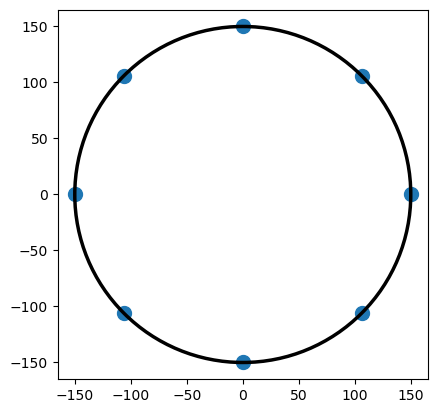

In [4]:
"""
Electrode positions
"""

radius = 150.0

electrode_angles = [0.0, 45.0, 90.0, 135.0, 180.0, 225.0, 270.0, 315.0]
electrode_positions = np.zeros((8, 2))
for i, e_ang in enumerate(electrode_angles):
    electrode_positions[i, 0] = radius*np.cos(np.deg2rad(e_ang))
    electrode_positions[i, 1] = radius*np.sin(np.deg2rad(e_ang))

fig, ax = plt.subplots()
ax.add_patch(ps.Circle(xy=(0,0), radius=radius, fill=None, lw=2.5, zorder=5))
ax.scatter(*electrode_positions.T, s=100)
ax.set_box_aspect(1)

In [26]:
num_fully_connected = 0
pos_list = []

cfg_dir = Path(f'/home/hd/hd_hd/hd_gy283/kmc_project/configs/')
#batch_save_dir.mkdir(exist_ok=True, parents=True)
num_of_tries = 0
ok = False
while not ok:
    out = gaussian_mixture_pos(radius=radius, n_a=200, n_comp=4, std_min=radius / 10, std_max=radius / 2)
    positions = np.concatenate([electrode_positions, out['positions']], axis=0)
    ok = subset_connected(positions, [0, 1, 2, 3, 4, 5, 6, 7], d_min=1.5, d_max=60.0)

    num_of_tries += 1
    print(f'Try: {num_of_tries}')
    
    if ok == True:
        cfg_save_dir = cfg_dir / f'gm_cfg_{num_fully_connected}.txt'
        #np.savetxt(fname=str(cfg_save_dir), X=out['positions'])
        print("Subset fully connected?", ok)
        break
#print(out)

Try: 1
Subset fully connected? True


(-152.0, 152.0)

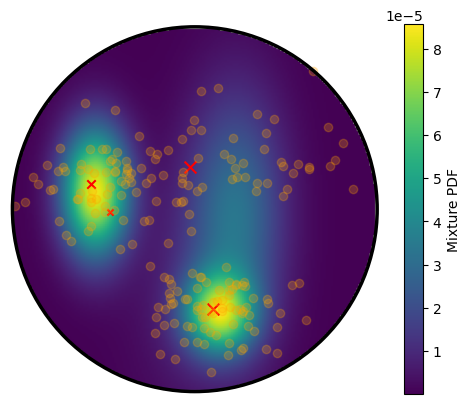

In [32]:
from scipy.stats import multivariate_normal

nx = ny = 200
disc_radius = radius
xx, yy = np.meshgrid(
    np.linspace(-disc_radius, disc_radius, nx),
    np.linspace(-disc_radius, disc_radius, ny)
)
grid = np.stack([xx, yy], axis=-1)
mask = (xx**2 + yy**2) <= radius**2

pdf = np.zeros(xx.shape)
for m, C, w in zip(out['means'], out['covs'], out['weights']):
    rv = multivariate_normal(mean=m, cov=C)
    pdf += w * rv.pdf(grid)

xmax = radius
xmin = -radius
ymax = radius
ymin = -radius
dx = (xmax - xmin) / (nx - 1)
dy = (ymax - ymin) / (ny - 1)
pdf_disc_unnorm = np.where(mask, pdf, 0.0)
Z = pdf_disc_unnorm.sum() * dx * dy
pdf_disc = pdf_disc_unnorm / Z

pdf_disc = np.where(mask, pdf_disc, np.nan)

fig, ax = plt.subplots()

im = ax.imshow(
    pdf_disc.T,
    origin='lower',
    extent=[-disc_radius, disc_radius, -disc_radius, disc_radius],
    cmap='viridis'
)
fig.colorbar(im, ax=ax, label='Mixture PDF')
for i in range(len(out['means'])):
    ax.scatter(out['means'][i][0], out['means'][i][1], s=out['weights'][i]*200, marker='x', c='r')

ax.set_box_aspect(1)

pos = sample(out['means'], out['covs'], out['weights'], radius, 200)
#ax.scatter(*out['positions'].T)
ax.scatter(*pos.T, c='orange', alpha=.25)
ax.add_patch(ps.Circle(xy=(0,0), radius=radius, fill=None, lw=2.5, zorder=5))
ax.spines[:].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
pad = 2.0
ax.set_xlim(left=-radius - pad, right=radius + pad)
ax.set_ylim(bottom=-radius - pad, top=radius + pad)

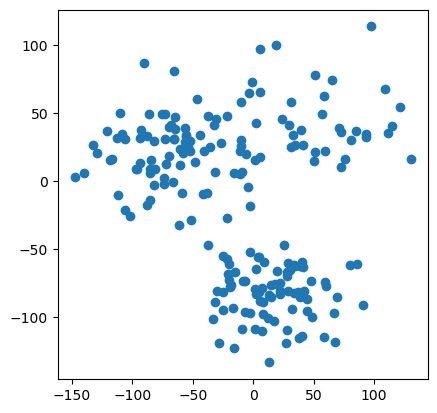

In [37]:
fig, ax = plt.subplots()
ax.set_box_aspect(1)
ax.scatter(*pos.T)
#np.savetxt('/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/data_gm_0/configs/gm_acceptors.txt', pos)
#np.savez('/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/data_gm_0/configs/gm_params.npz', out['weights'], out['covs'], out['means'])

15.0
75.0


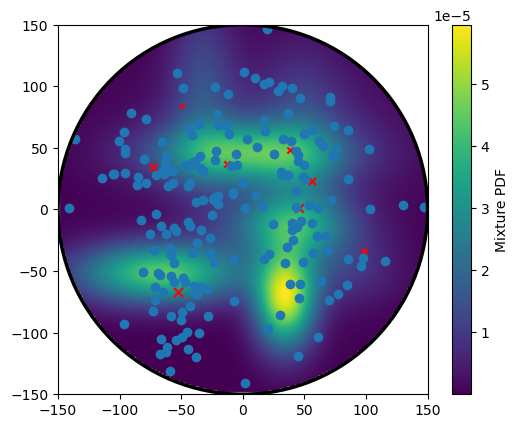

In [164]:
from scipy.stats import multivariate_normal

mean = [0., 0.]
radius = 150.0
n_a = 200
R = np.sqrt(np.pi*radius**2 / n_a)
std_min = radius / 10.0
std_max = radius / 2.0

print(std_min)
print(std_max)

num_comps = 8
out = gaussian_mixture_pos(radius, n_a, num_comps, std_min, std_max)

nx = ny = 200
disc_radius = radius
xx, yy = np.meshgrid(
    np.linspace(-disc_radius, disc_radius, nx),
    np.linspace(-disc_radius, disc_radius, ny)
)
grid = np.stack([xx, yy], axis=-1)
mask = (xx**2 + yy**2) <= radius**2

pdf = np.zeros(xx.shape)
for m, C, w in zip(out['means'], out['covs'], out['weights']):
    rv = multivariate_normal(mean=m, cov=C)
    pdf += w * rv.pdf(grid)

xmax = radius
xmin = -radius
ymax = radius
ymin = -radius
dx = (xmax - xmin) / (nx - 1)
dy = (ymax - ymin) / (ny - 1)
pdf_disc_unnorm = np.where(mask, pdf, 0.0)
Z = pdf_disc_unnorm.sum() * dx * dy
pdf_disc = pdf_disc_unnorm / Z

pdf_disc = np.where(mask, pdf_disc, np.nan)

fig, ax = plt.subplots()

im = ax.imshow(
    pdf_disc.T,
    origin='lower',
    extent=[-disc_radius, disc_radius, -disc_radius, disc_radius],
    cmap='viridis'
)
fig.colorbar(im, ax=ax, label='Mixture PDF')

for i in range(num_comps):
    ax.scatter(out['means'][i][0], out['means'][i][1], s=out['weights'][i]*200, marker='x', c='r')

ax.set_box_aspect(1)
ax.scatter(*out['positions'].T)
ax.add_patch(ps.Circle(xy=(0,0), radius=radius, fill=None, lw=2.5, zorder=5))

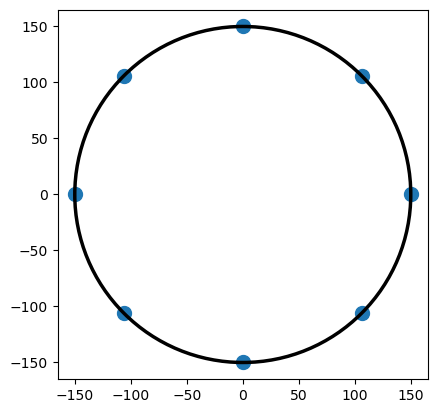

In [3]:
radius = 150.0

electrode_angles = [0.0, 45.0, 90.0, 135.0, 180.0, 225.0, 270.0, 315.0]
electrode_positions = np.zeros((8, 2))
for i, e_ang in enumerate(electrode_angles):
    electrode_positions[i, 0] = radius*np.cos(np.deg2rad(e_ang))
    electrode_positions[i, 1] = radius*np.sin(np.deg2rad(e_ang))

fig, ax = plt.subplots()
ax.add_patch(ps.Circle(xy=(0,0), radius=radius, fill=None, lw=2.5, zorder=5))
ax.scatter(*electrode_positions.T, s=100)
ax.set_box_aspect(1)

In [4]:
num_fully_connected = 0
pos_list = []

n_batches = 200
batch_size = 1_000

for j in range(34, n_batches):
    batch_save_dir = Path(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/gm_configs/batch_{j}')
    batch_save_dir.mkdir(exist_ok=True, parents=True)
    while num_fully_connected < batch_size:
        out = gaussian_mixture_pos(radius=radius, n_a=200, n_comp=3, std_min=radius / 3.0, std_max=radius / 2.0)
        positions = np.concatenate([electrode_positions, out['positions']], axis=0)
        ok = subset_connected(positions, [0, 1, 2, 3, 4, 5, 6, 7], d_min=1.5, d_max=60.0)
        if ok == True:
            num_fully_connected += 1
            pos_list.append(out['positions'])
            cfg_save_dir = batch_save_dir / f'gm_cfg_{num_fully_connected}.txt'
            np.savetxt(fname=str(cfg_save_dir), X=out['positions'])
        # print("Subset fully connected?", ok)
    num_fully_connected = 0
    print(j)

34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199


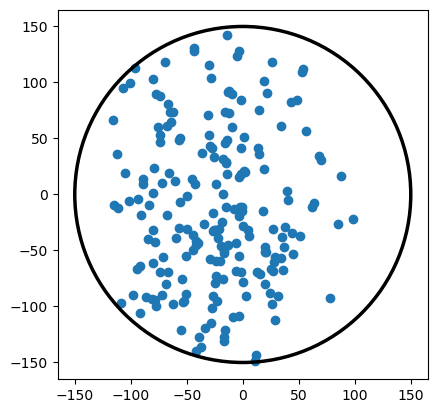

In [125]:
idx = np.random.randint(1, 1000)

pos = np.loadtxt(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/gm_configs/batch_0/gm_cfg_{idx}.txt')

fig, ax = plt.subplots()
ax. set_box_aspect(1)
ax.add_patch(ps.Circle(xy=(0,0), radius=radius, fill=None, lw=2.5, zorder=5))
ax.scatter(*pos.T)